# Performance Testing

- general statistical methods for evaluation
- downstream task: train two models and use real data as validation set

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance

In [3]:
real = pd.read_csv("../datasets/filtered.csv", engine="pyarrow")
# synth = pd.read_csv("../output/after-calib.csv", engine="pyarrow")

In [26]:
numeric_cols = real.select_dtypes(include=np.number).columns.intersection(
    synth.select_dtypes(include=np.number).columns
)

selected_cols = [
    'st_dirs',
    'st_successful',
    'st_failed',
    'st_expired',
    'st_canceled',
    'st_faults',
    'st_bytes_xfered',
    'st_xfer_time_ms'
]

# Ensure both datasets contain these columns
real = real[selected_cols].dropna()
synth = synth[selected_cols].dropna()

print(f"Validating {len(selected_cols)} transfer-related features.\n")

Validating 8 transfer-related features.



In [23]:
stats_real = real.describe().T[['mean', 'std', 'min', 'max']]
stats_synth = synth.describe().T[['mean', 'std', 'min', 'max']]
summary = pd.concat(
    [stats_real.add_suffix('_real'), stats_synth.add_suffix('_synth')],
    axis=1
)
summary_json = summary.reset_index(names="feature").to_json(orient="records")
print("After Calibration & Before Clipping")
print("Descriptive statistics (real vs synthetic):")
print(summary)
print("JSON format:")
print(summary_json)

After Calibration & Before Clipping
Descriptive statistics (real vs synthetic):
                    mean_real      std_real  min_real      max_real  \
st_dirs          3.165675e+02  3.371757e+04       0.0  8.791225e+07   
st_successful    4.519742e+03  2.529234e+05       0.0  5.114859e+08   
st_failed        4.972352e+01  5.160599e+04       0.0  1.440816e+08   
st_expired       5.304780e+02  1.934975e+05       0.0  4.457491e+08   
st_canceled      9.686416e+02  1.760280e+05       0.0  2.807579e+08   
st_faults        5.122567e+00  7.664199e+01       0.0  1.182540e+05   
st_bytes_xfered  5.600996e+10  2.698348e+12       0.0  7.802815e+15   
st_xfer_time_ms  8.983515e+05  1.889429e+07       0.0  1.482032e+10   

                   mean_synth     std_synth  min_synth     max_synth  
st_dirs          1.037291e+00  3.217148e+01        0.0  8.805500e+04  
st_successful    2.412036e+07  7.478450e+10        0.0  2.765775e+14  
st_failed        4.834989e-08  2.198861e-04        0.0  1.000000e+0

In [27]:
def sigma_filter(df, column: str, k: float = 3.0):
    mu = df[column].mean()
    sigma = df[column].std()
    lower, upper = mu - k * sigma, mu + k * sigma
    return df[(df[column] >= lower) & (df[column] <= upper)]

k = 1  # number of sigmas
real_filtered = sigma_filter(real, "st_bytes_xfered", k=k)
synth_filtered = sigma_filter(synth, "st_bytes_xfered", k=k)
real_filtered = sigma_filter(real, "st_xfer_time_ms", k=k)
synth_filtered = sigma_filter(synth, "st_xfer_time_ms", k=k)

In [28]:
stats_real = real_filtered.describe().T[['mean', 'std', 'min', 'max']]
stats_synth = synth_filtered.describe().T[['mean', 'std', 'min', 'max']]
summary = pd.concat(
    [stats_real.add_suffix('_real'), stats_synth.add_suffix('_synth')],
    axis=1
)
summary_json = summary.reset_index(names="feature").to_json(orient="records")
print("Descriptive statistics (real vs synthetic):")
print(summary)
print("JSON format:")
print(summary_json)

Descriptive statistics (real vs synthetic):
                    mean_real      std_real  min_real      max_real  \
st_dirs          2.308111e+02  1.543446e+04       0.0  2.800850e+07   
st_successful    3.152865e+03  1.260631e+05       0.0  2.491708e+08   
st_failed        3.976588e+01  4.536929e+04       0.0  1.440816e+08   
st_expired       2.630641e+02  1.257459e+05       0.0  3.571345e+08   
st_canceled      6.032249e+02  1.280574e+05       0.0  2.795662e+08   
st_faults        3.963231e+00  5.120141e+01       0.0  3.433400e+04   
st_bytes_xfered  2.214863e+10  4.195223e+11       0.0  2.641811e+14   
st_xfer_time_ms  2.117900e+05  1.213395e+06       0.0  1.979260e+07   

                   mean_synth     std_synth  min_synth     max_synth  
st_dirs          1.037287e+00  3.217159e+01        0.0  8.805500e+04  
st_successful    2.412053e+07  7.478476e+10        0.0  2.765775e+14  
st_failed        4.835023e-08  2.198869e-04        0.0  1.000000e+00  
st_expired       1.833194e-02  6

In [20]:
for col in ["st_bytes_xfered", "st_xfer_time_ms"]:
    print(col, "real q99/q999:", np.quantile(real[col], [0.99, 0.999, 0.99999, 0.999999]))
    print(col, "synth q99/q999:", np.quantile(synth[col], [0.99, 0.999, 0.99999, 0.999999]))

st_bytes_xfered real q99/q999: [5.59270485e+11 8.82184325e+12 2.13763543e+14 9.73569157e+14]
st_bytes_xfered synth q99/q999: [5.59270252e+11 8.82181518e+12 2.13775843e+14 2.17051950e+15]
st_xfer_time_ms real q99/q999: [1.29402975e+07 1.44446939e+08 2.14459474e+09 5.02160378e+09]
st_xfer_time_ms synth q99/q999: [1.29402975e+07 1.44446939e+08 2.14488621e+09 6.56334937e+10]


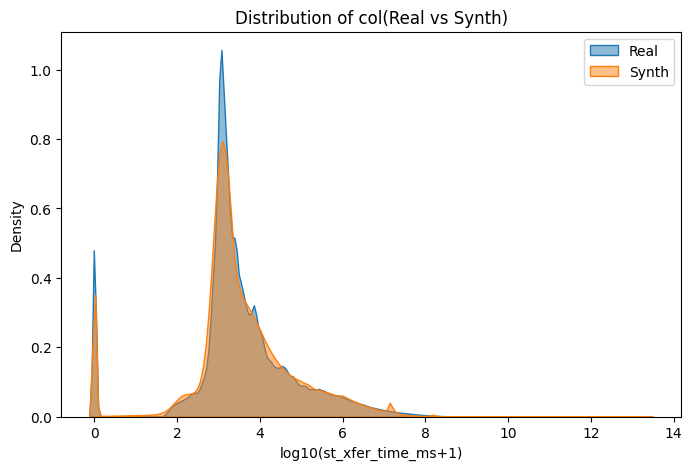

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
 
# Plot the distributions
col = "st_xfer_time_ms"
plt.figure(figsize=(8, 5))

real_log = np.log10(real[col].clip(lower=1))
synth_log = np.log10(synth[col].clip(lower=1))

sns.kdeplot(real_log, label="Real", fill=True, alpha=0.5)
sns.kdeplot(synth_log, label="Synth", fill=True, alpha=0.5)
plt.title("Distribution of col(Real vs Synth)")
plt.xlabel(f'log10({col}+1)')
plt.ylabel("Density")
plt.legend()
plt.show()


In [30]:
ks_results, wd_results = {}, {}
for col in selected_cols:
    ks = ks_2samp(real_filtered[col], synth_filtered[col]).statistic
    wd = wasserstein_distance(real_filtered[col], synth_filtered[col])
    ks_results[col] = ks
    wd_results[col] = wd

ks_df = pd.DataFrame({'KS_stat': ks_results, 'Wasserstein': wd_results})
print("\nDistribution similarity (lower is better):")
print(ks_df.sort_values('KS_stat'))


Distribution similarity (lower is better):
                  KS_stat   Wasserstein
st_failed        0.000201  3.976588e+01
st_expired       0.002258  2.630458e+02
st_canceled      0.009486  6.031726e+02
st_faults        0.021179  3.847737e+00
st_xfer_time_ms  0.036502  4.509115e+05
st_successful    0.045872  2.411934e+07
st_dirs          0.048864  2.297738e+02
st_bytes_xfered  0.068319  3.076686e+10


In [17]:
# Should this be included in the code?

synth.loc[synth["st_bytes_xfered"] > real["st_bytes_xfered"].max(), "st_bytes_xfered"] = real["st_bytes_xfered"].max()
synth.loc[synth["st_xfer_time_ms"] > real["st_xfer_time_ms"].max(), "st_xfer_time_ms"] = real["st_xfer_time_ms"].max()

In [11]:
print("real")
print(np.percentile(real.st_bytes_xfered, 99))
print(np.percentile(real.st_bytes_xfered, 95))
print(np.percentile(real.st_bytes_xfered, 90))
print("synth")
print(np.percentile(synth.st_bytes_xfered, 99))
print(np.percentile(synth.st_bytes_xfered, 95))
print(np.percentile(synth.st_bytes_xfered, 90))


real
559270485228.0292
35716142276.899826
6277237687.3
synth
737393162699.9988
34576237000.0
6239471050.0000305


In [12]:
print("real")
print(np.percentile(real.st_xfer_time_ms, 99))
print(np.percentile(real.st_xfer_time_ms, 95))
print(np.percentile(real.st_xfer_time_ms, 90))
print(np.percentile(real.st_xfer_time_ms, 50))
print(np.percentile(real.st_xfer_time_ms, 30))
print("synth")
print(np.percentile(synth.st_xfer_time_ms, 99))
print(np.percentile(synth.st_xfer_time_ms, 95))
print(np.percentile(synth.st_xfer_time_ms, 90))
print(np.percentile(synth.st_xfer_time_ms, 50))
print(np.percentile(synth.st_xfer_time_ms, 30))

real
12940297.489999995
882872.049999997
172722.0
2193.0
1188.0
synth
12144543.0
748005.06
157328.12
2241.1697
1173.8448


In [31]:
realdata = real_filtered
synthdata = synth_filtered
corr_real = realdata.corr()
corr_synth = synthdata.corr()

# Drop columns that annihilate correlation
zero_var = realdata.columns[(realdata.nunique() <= 1) | (synthdata.nunique() <= 1)]
real_corr_input = realdata.drop(columns=zero_var)
synth_corr_input = synthdata.drop(columns=zero_var)
corr_real = real_corr_input.corr()
corr_synth = synth_corr_input.corr()
corr_diff = np.linalg.norm(corr_real - corr_synth, 'fro')

corr_diff_matrix = (corr_real - corr_synth).abs()

# Flatten to pairs for readability
corr_diff_pairs = (
    corr_diff_matrix
    .where(np.triu(np.ones(corr_diff_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_diff_pairs.columns = ['Feature1', 'Feature2', 'Abs_Diff']

# Sort by difference magnitude
corr_diff_pairs = corr_diff_pairs.sort_values('Abs_Diff', ascending=False)
print("Top correlation differences:")
print(corr_diff)
print(corr_diff_pairs.head(10))


Top correlation differences:
0.9141127737921133
           Feature1         Feature2  Abs_Diff
2           st_dirs       st_expired  0.405900
3           st_dirs      st_canceled  0.394089
27  st_bytes_xfered  st_xfer_time_ms  0.205320
0           st_dirs    st_successful  0.201293
26        st_faults  st_xfer_time_ms  0.084816
12    st_successful  st_xfer_time_ms  0.038033
4           st_dirs        st_faults  0.032744
7     st_successful        st_failed  0.029133
9     st_successful      st_canceled  0.028384
11    st_successful  st_bytes_xfered  0.027099
